In [14]:
# Generate 2D points and save to CSV (no header)
import numpy as np

rng = np.random.default_rng(42)  # reproducible
centers = np.array([[0.0, 0.0], [5.0, 5.0], [-5.0, 5.0]])
cluster_std = [0.8, 0.8, 0.8]
n_samples = 10000000

points_list = []
base = n_samples // len(centers)
remainder = n_samples - base * len(centers)
counts = [base + (1 if i < remainder else 0) for i in range(len(centers))]

for c, std, count in zip(centers, cluster_std, counts):
    pts = rng.normal(loc=c, scale=std, size=(count, 2))
    points_list.append(pts)

points = np.vstack(points_list)
rng.shuffle(points)

# Save as CSV with two columns x,y and no header
np.savetxt("points10M.csv", points, delimiter=",", fmt="%.6f")

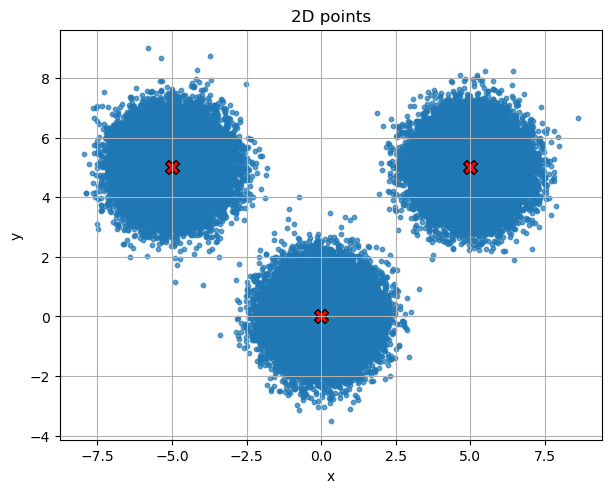

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(points[:, 0], points[:, 1], s=10, alpha=0.7)
# show cluster centers if available
try:
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', edgecolors='k')
except Exception:
    pass
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D points')
plt.grid(True)
plt.show()